In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
raw_filepath = './datasets/raw/'
processed_filepath = './datasets/processed/'
working_filepath = './datasets/working/'

In [4]:
def load_n_copy_dat(dataset, filepath):
    file_path = filepath + dataset
    df = pd.read_csv(file_path)
    print("Wymiary", dataset, ":", df.shape)
    print(df.columns.tolist())
    return df.copy()

t = load_n_copy_dat('Tuesday-WorkingHours.pcap_ISCX.csv', raw_filepath)
w = load_n_copy_dat('Wednesday-workingHours.pcap_ISCX.csv', raw_filepath)
tm = load_n_copy_dat('Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', raw_filepath)
ta = load_n_copy_dat('Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', raw_filepath)
fm = load_n_copy_dat('Friday-WorkingHours-Morning.pcap_ISCX.csv', raw_filepath)
fap = load_n_copy_dat('Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', raw_filepath)
fad = load_n_copy_dat('Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', raw_filepath)

t.head()

Wymiary Tuesday-WorkingHours.pcap_ISCX.csv : (445909, 79)
[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,88,640,7,4,440,358,220,0,62.857143,107.349008,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,88,900,9,4,600,2944,300,0,66.666667,132.287566,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1205,7,4,2776,2830,1388,0,396.571429,677.274651,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,88,511,7,4,452,370,226,0,64.571429,110.276708,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,773,9,4,612,2944,306,0,68.000000,134.933317,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [5]:
def check_attribute_labels(datasets):
    datasets = [set(dataset) for dataset in datasets]
    
    if all(datasets[0] == dataset for dataset in datasets):
        print("Nazwy kolumn są identyczne.\n")
    else:
        print("Nazwy kolumn różnią się między DataFrame.")


datasets = [t, w, tm, ta, fm, fap, fad]
check_attribute_labels(datasets)

Nazwy kolumn są identyczne.



In [6]:
def print_unique_labels_with_dataset_names(datasets):
    for dataset, name in datasets:
        dataset.columns = dataset.columns.str.strip()
        print(f"Unikalne wartości w kolumnie 'Label' ({name}):")
        print(dataset['Label'].unique())

datasets = [(t, "Tuesday"), 
            (w, "Wednesday"), 
            (tm, "Thursday Morning"), (ta, "Thursday Afternoon"), 
            (fm, "Friday Morning"), (fap, "Friday Afternoon - P"), (fad, "Friday Afternoon - D")]
print_unique_labels_with_dataset_names(datasets)

Unikalne wartości w kolumnie 'Label' (Tuesday):
['BENIGN' 'FTP-Patator' 'SSH-Patator']
Unikalne wartości w kolumnie 'Label' (Wednesday):
['BENIGN' 'DoS slowloris' 'DoS Slowhttptest' 'DoS Hulk' 'DoS GoldenEye'
 'Heartbleed']
Unikalne wartości w kolumnie 'Label' (Thursday Morning):
['BENIGN' 'Web Attack � Brute Force' 'Web Attack � XSS'
 'Web Attack � Sql Injection']
Unikalne wartości w kolumnie 'Label' (Thursday Afternoon):
['BENIGN' 'Infiltration']
Unikalne wartości w kolumnie 'Label' (Friday Morning):
['BENIGN' 'Bot']
Unikalne wartości w kolumnie 'Label' (Friday Afternoon - P):
['BENIGN' 'PortScan']
Unikalne wartości w kolumnie 'Label' (Friday Afternoon - D):
['BENIGN' 'DDoS']


In [7]:
def save_to_csv(*args, name, filepath):
    if len(args) == 1:
        df = args[0]
        print(f"Zapisuję pojedynczy plik: {name}.csv")
    else:
        df = pd.concat(args, ignore_index=True)
        print(f"Łączę {len(args)} plików w jeden: {name}.csv")

    print("Wymiary", name, ":", df.shape)
    df.to_csv(f'{filepath}{name}.csv', index=False)
    print(f"Plik {name}.csv zapisano pomyślnie.")

In [8]:
save_to_csv(t, name="X_Working_Tuesday", filepath=working_filepath)
save_to_csv(w, name="X_Working_Wednesday", filepath=working_filepath)
save_to_csv(tm, ta, name="X_Working_Thursday", filepath=working_filepath)
save_to_csv(fm, fap, fad, name="X_Working_Friday", filepath=working_filepath)

Zapisuję pojedynczy plik: X_Working_Tuesday.csv
Wymiary X_Working_Tuesday : (445909, 79)
Plik X_Working_Tuesday.csv zapisano pomyślnie.
Zapisuję pojedynczy plik: X_Working_Wednesday.csv
Wymiary X_Working_Wednesday : (692703, 79)
Plik X_Working_Wednesday.csv zapisano pomyślnie.
Łączę 2 plików w jeden: X_Working_Thursday.csv
Wymiary X_Working_Thursday : (458968, 79)
Plik X_Working_Thursday.csv zapisano pomyślnie.
Łączę 3 plików w jeden: X_Working_Friday.csv
Wymiary X_Working_Friday : (703245, 79)
Plik X_Working_Friday.csv zapisano pomyślnie.


In [9]:
tuesday = load_n_copy_dat('X_Working_Tuesday.csv', filepath=working_filepath)
wednesday = load_n_copy_dat('X_Working_Wednesday.csv', filepath=working_filepath)
thursday = load_n_copy_dat('X_Working_Thursday.csv', filepath=working_filepath)
friday = load_n_copy_dat('X_Working_Friday.csv', filepath=working_filepath)

Wymiary X_Working_Tuesday.csv : (445909, 79)
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG F

In [10]:
print(tuesday.columns.tolist())
print(wednesday.columns.tolist())
print(thursday.columns.tolist())
print(friday.columns.tolist())

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count

In [12]:
def encode_columns(df, name):
    label_encoder = LabelEncoder() 
    flag = "2D"
    if flag ==  "MD":
        label_encoder = LabelEncoder()
        df['Label'] = label_encoder.fit_transform(df['Label'])
        print("Etykiety odpowiadające wartościom liczbowym:")
        for i in range(len(label_encoder.classes_)):
            print(f"{i}: {label_encoder.classes_[i]}")
    elif flag == "2D":
        df['Label'] = df['Label'].map(lambda x: 0 if x == "BENIGN" else 1)
    print(f"Unikalne wartości w kolumnie 'Label' - ({name}):")
    print(df['Label'].unique())
    print(df['Label'].value_counts()) 

encode_columns(tuesday, "Tuesday")
encode_columns(wednesday, "Wednesday")
encode_columns(thursday, "Thursday")
encode_columns(friday, "Friday")

Unikalne wartości w kolumnie 'Label' - (Tuesday):
[0 1]
Label
0    432074
1     13835
Name: count, dtype: int64
Unikalne wartości w kolumnie 'Label' - (Wednesday):
[0 1]
Label
0    440031
1    252672
Name: count, dtype: int64
Unikalne wartości w kolumnie 'Label' - (Thursday):
[0 1]
Label
0    456752
1      2216
Name: count, dtype: int64
Unikalne wartości w kolumnie 'Label' - (Friday):
[0 1]
Label
0    414322
1    288923
Name: count, dtype: int64


In [13]:
def drop_rows(df, name):
    rows_before = df.shape[0]
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)
    rows_after = df.shape[0]
    rows_dropped = rows_before - rows_after
    print(f"Liczba wierszy usuniętych - ({name}): {rows_dropped}")

drop_rows(tuesday, "Tuesday")
drop_rows(wednesday, "Wednesday")
drop_rows(thursday, "Thursday")
drop_rows(friday, "Friday")

Liczba wierszy usuniętych - (Tuesday): 264
Liczba wierszy usuniętych - (Wednesday): 1297
Liczba wierszy usuniętych - (Thursday): 342
Liczba wierszy usuniętych - (Friday): 527


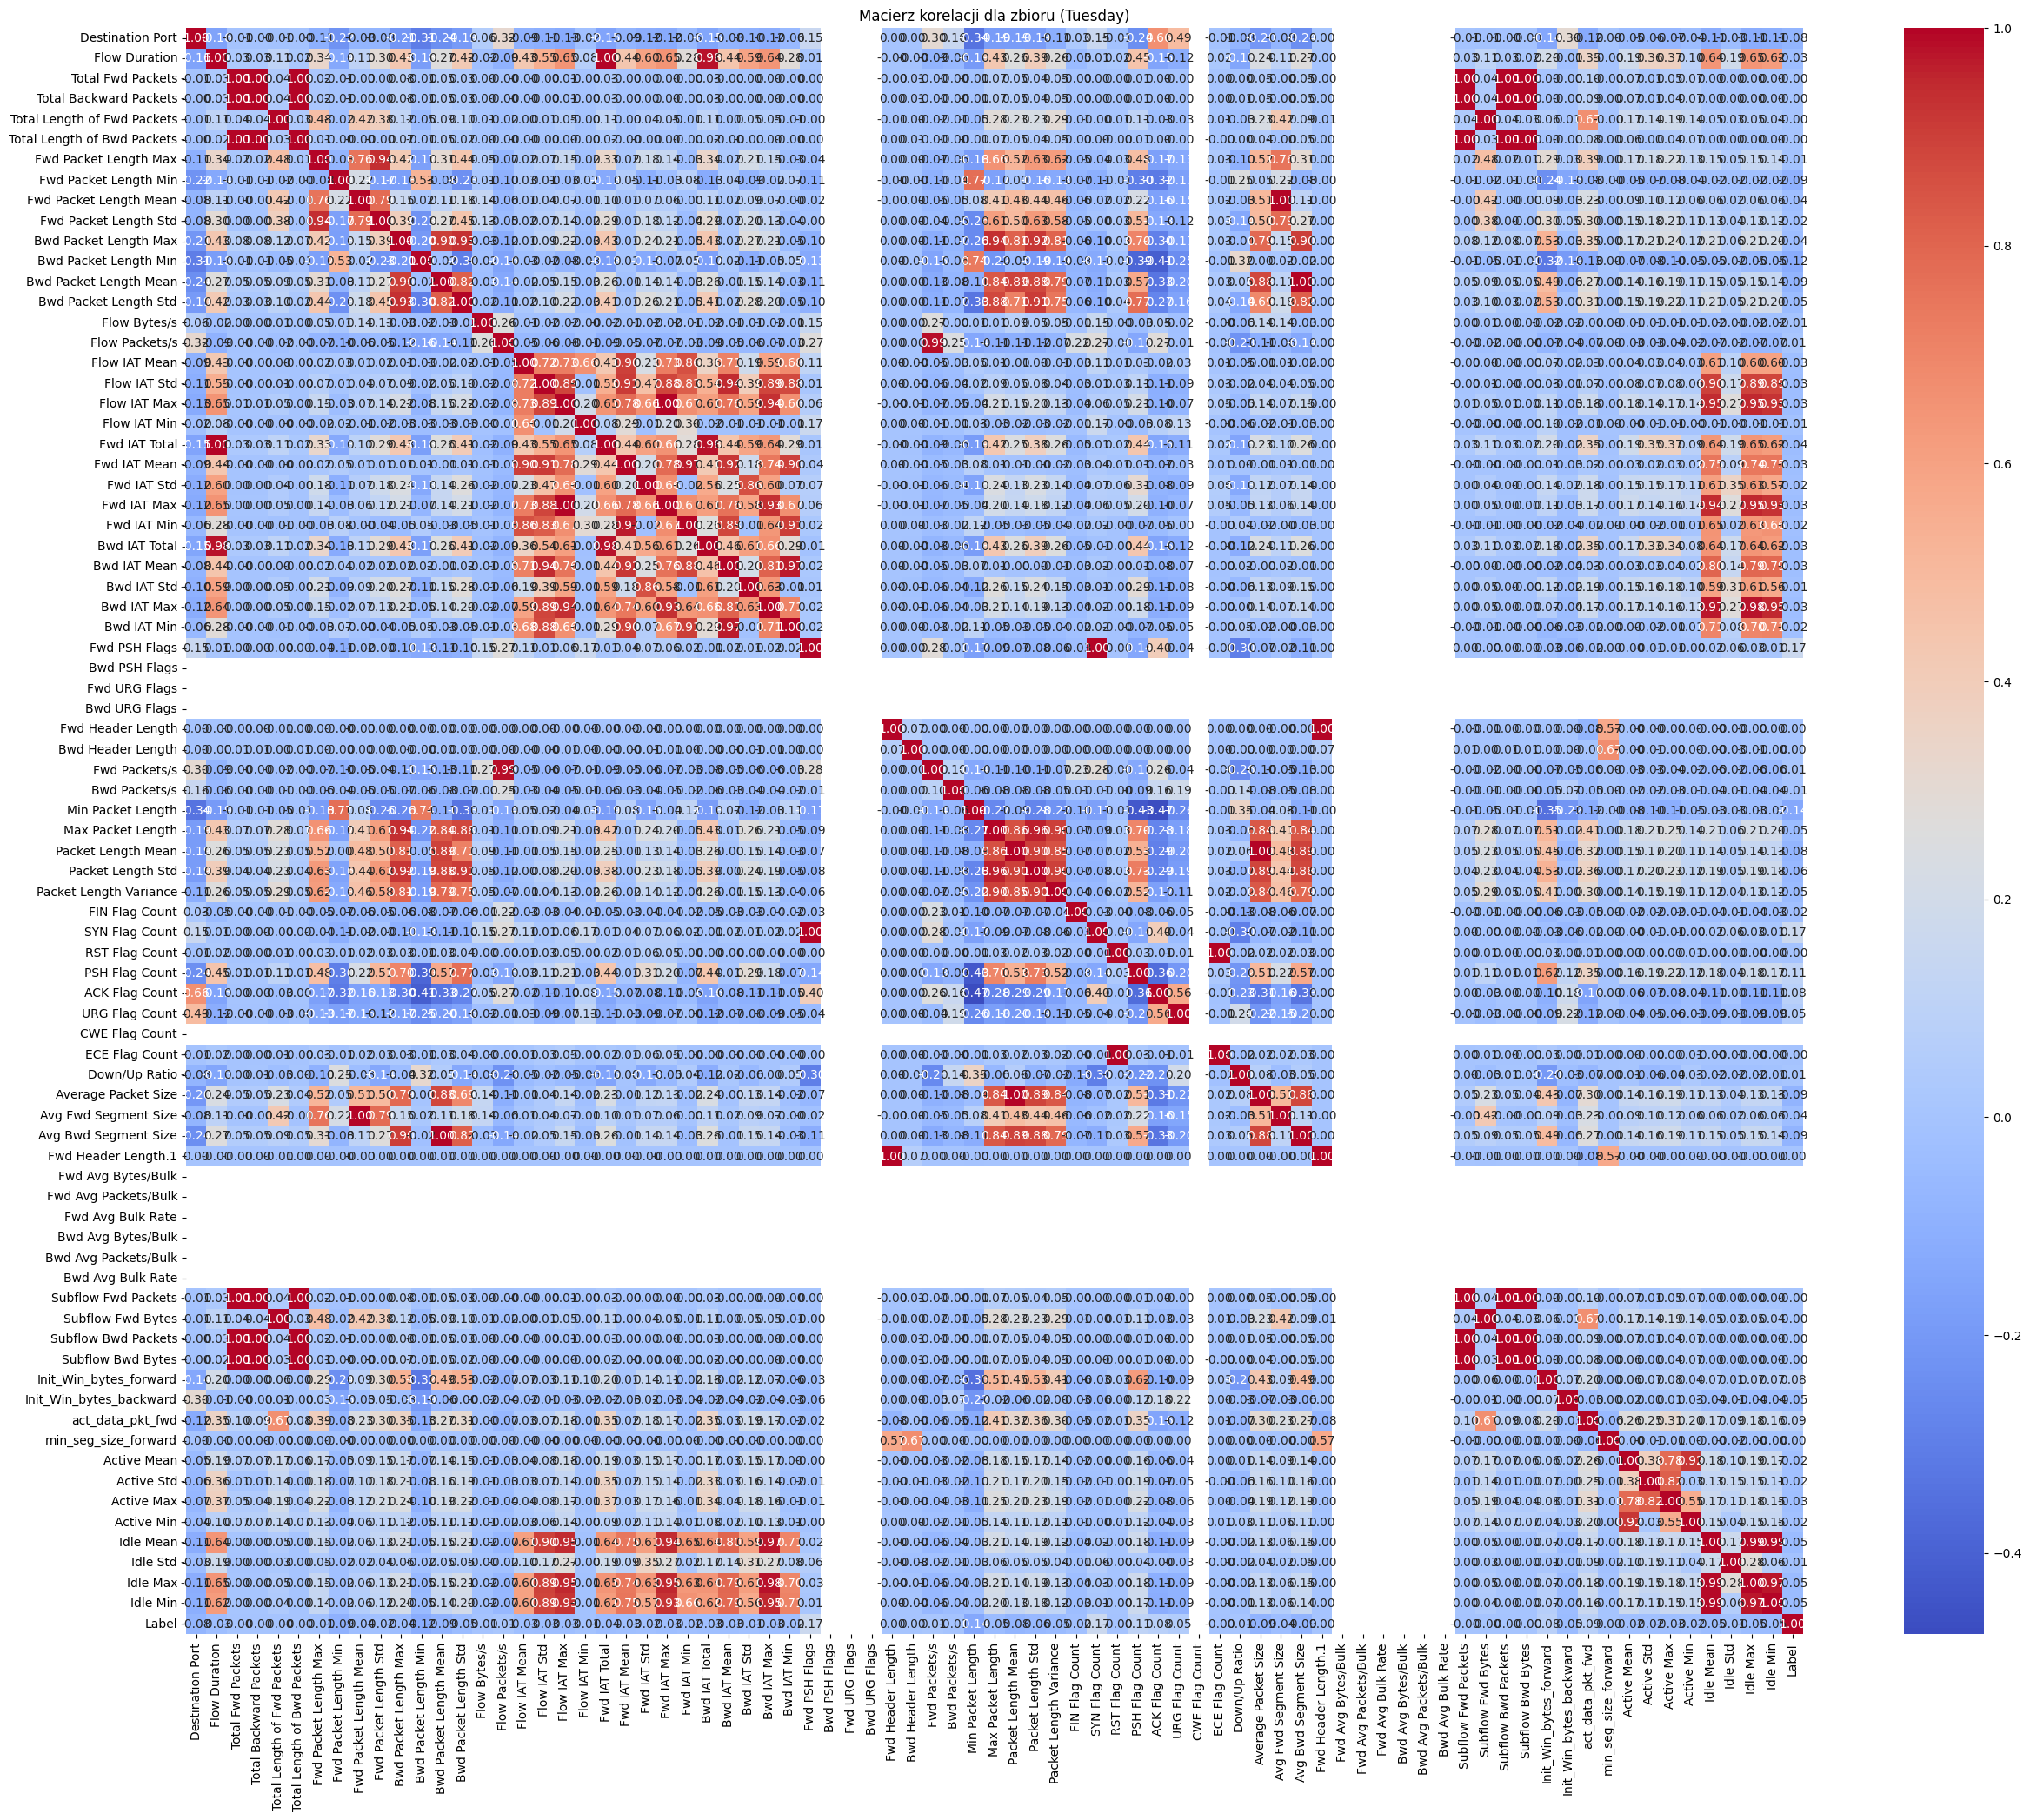

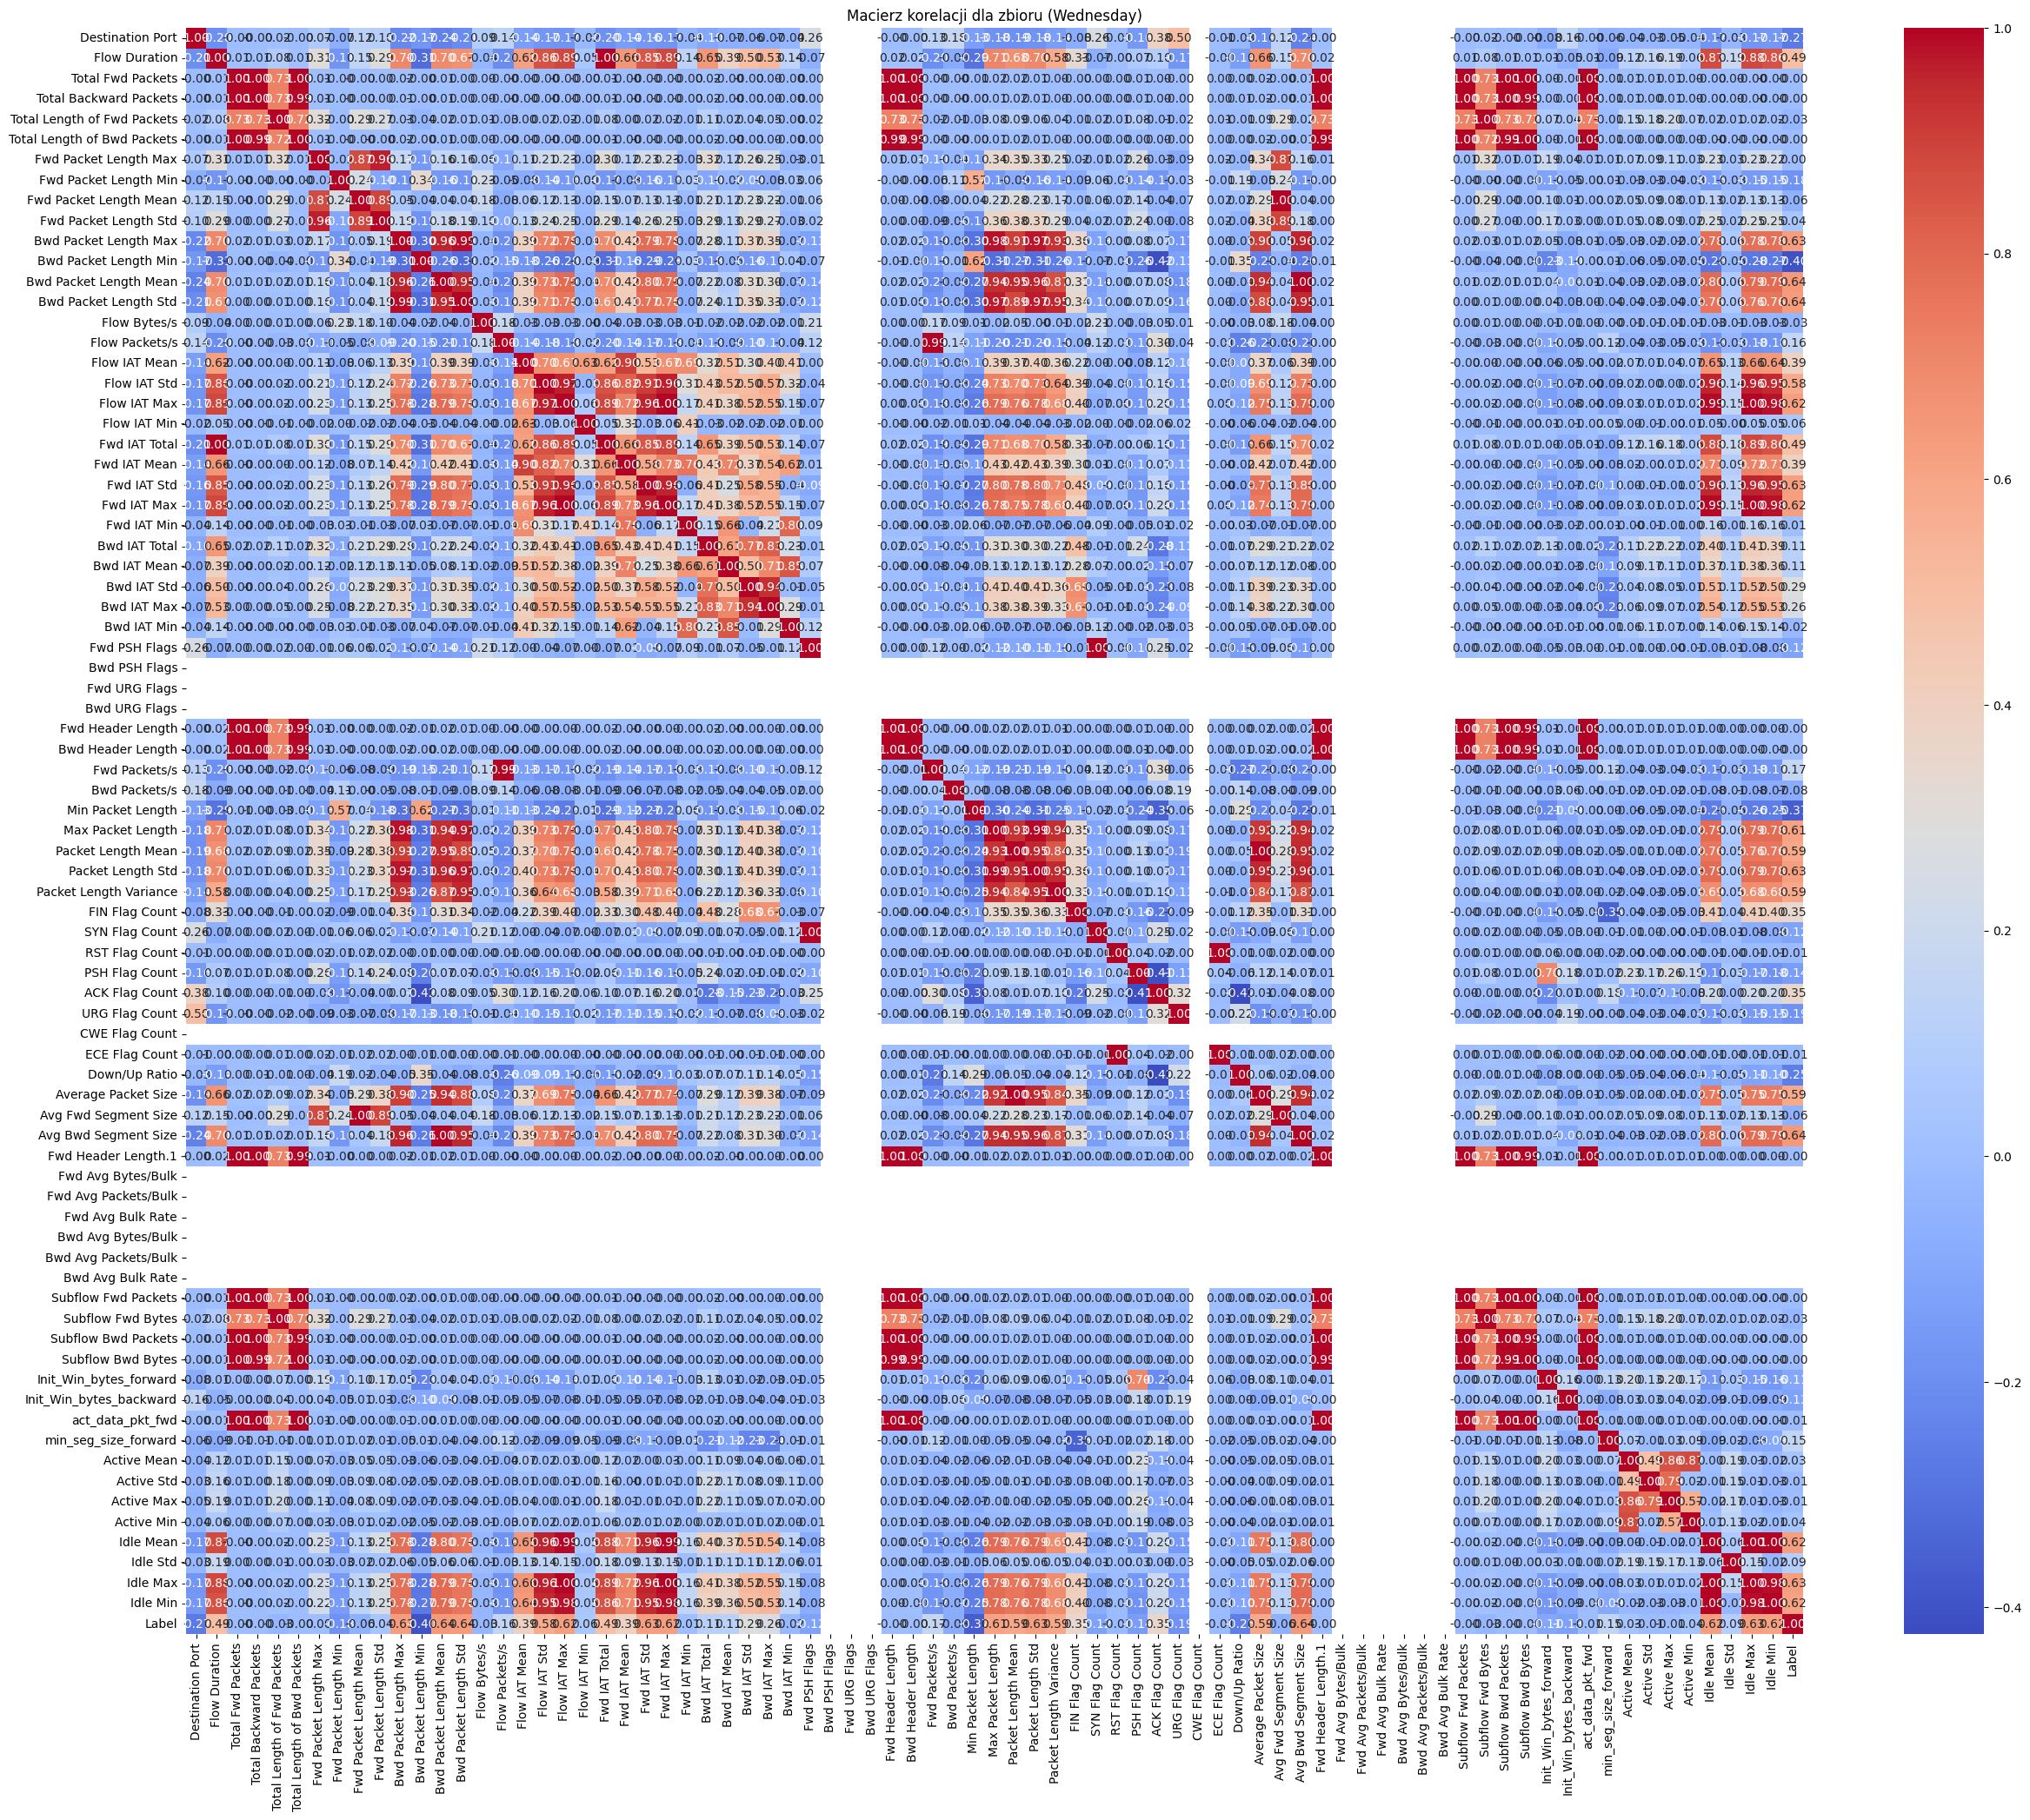

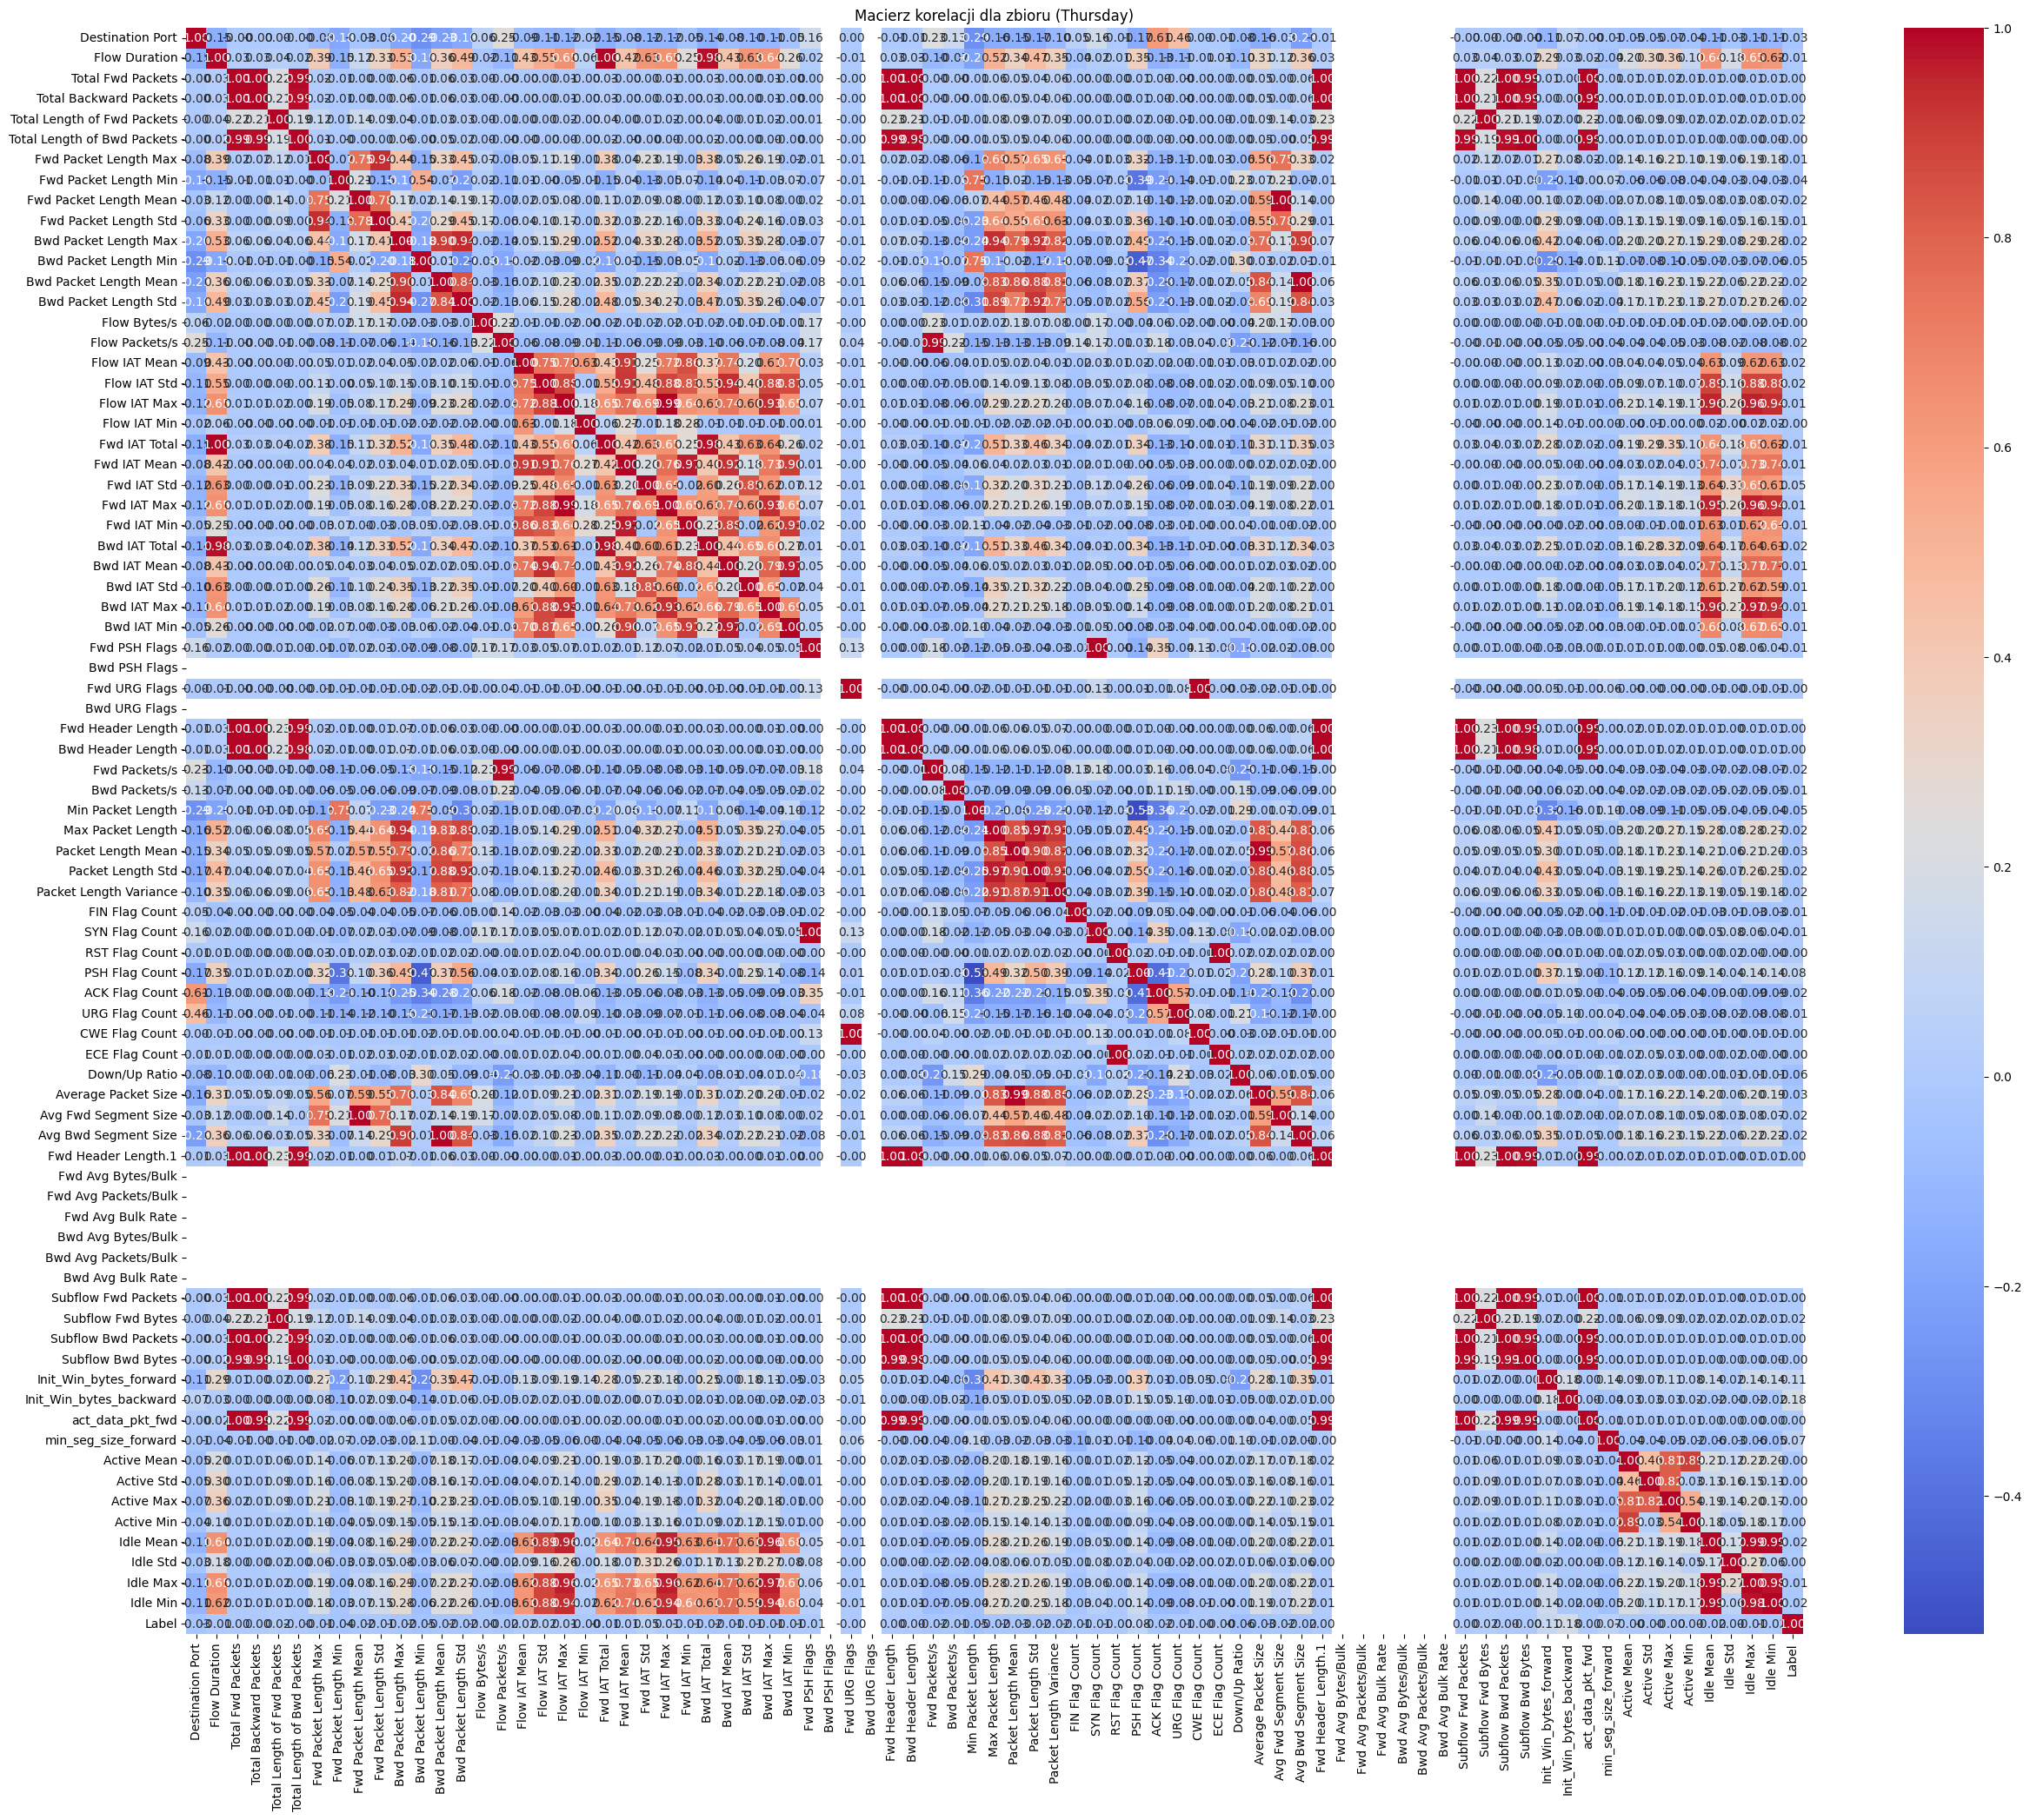

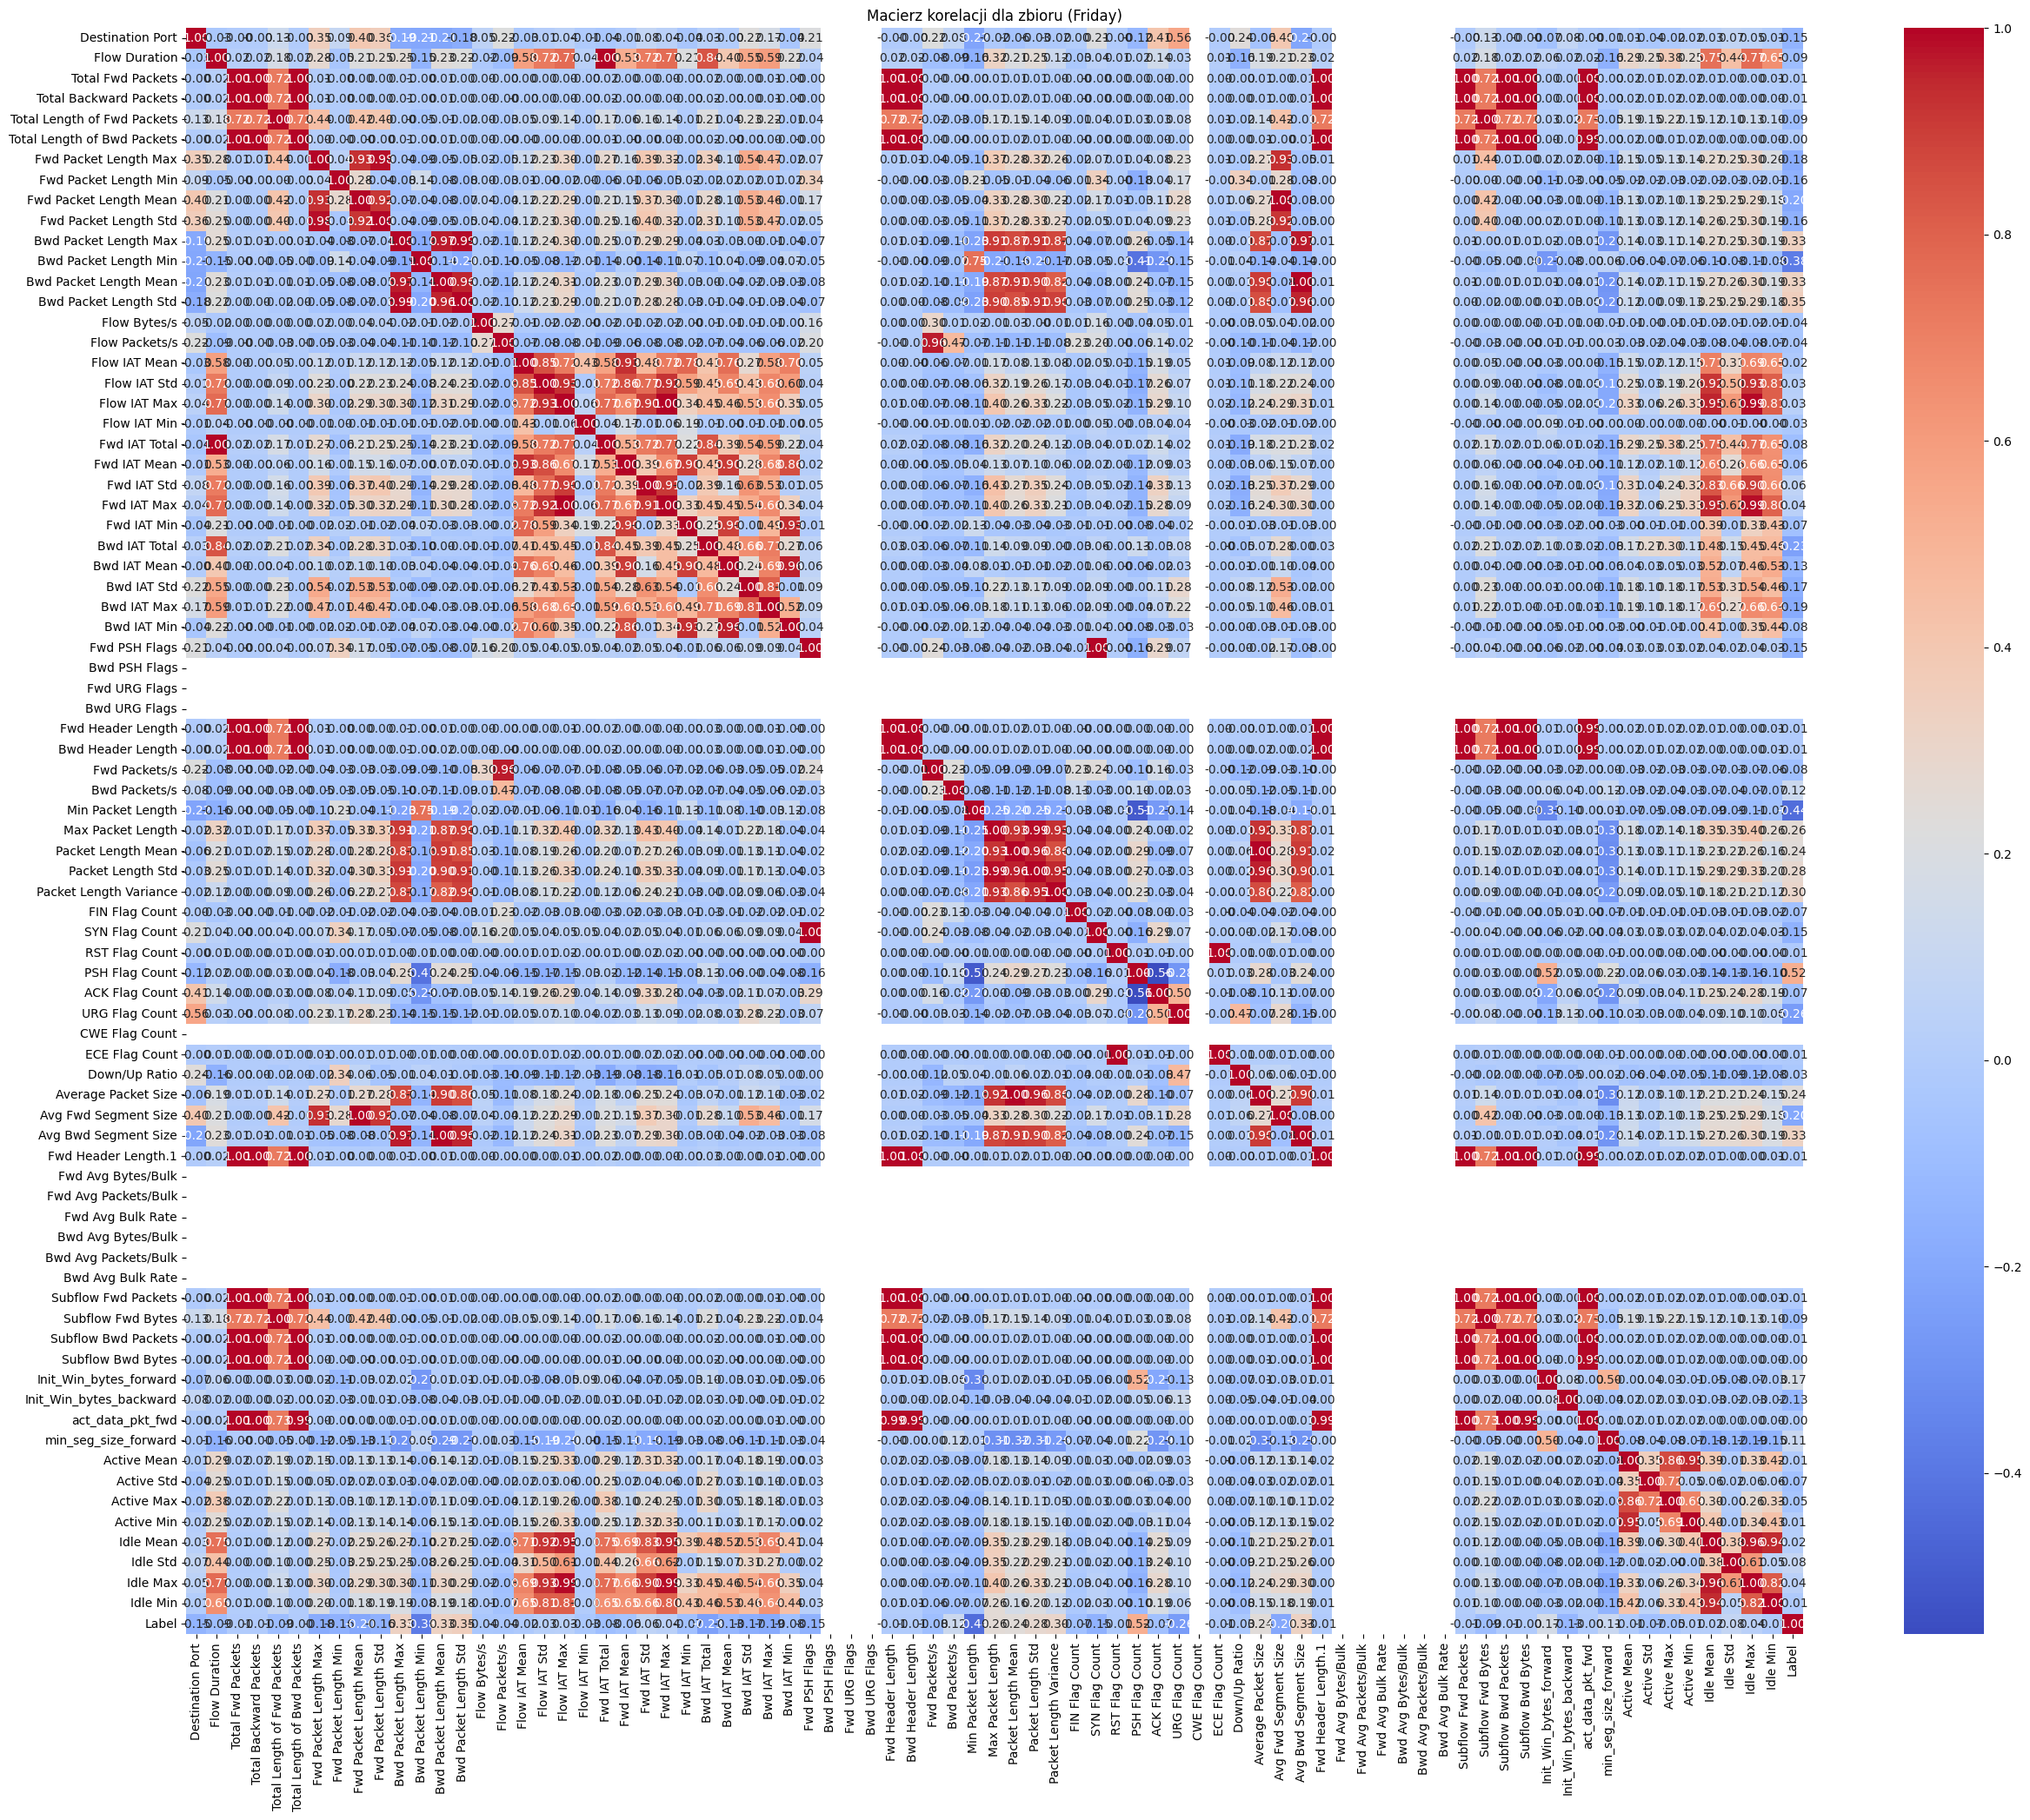

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_correlation_heatmap(df, name):
    numeric_df = df.select_dtypes(include=[np.number])
    correlation_matrix = numeric_df.corr()
    
    plt.figure(figsize=(30, 24)) 
    sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
    plt.title(f"Macierz korelacji dla zbioru ({name})")
    plt.show()

plot_correlation_heatmap(tuesday, "Tuesday")
plot_correlation_heatmap(wednesday, "Wednesday")
plot_correlation_heatmap(thursday, "Thursday")
plot_correlation_heatmap(friday, "Friday")

In [15]:
save_to_csv(tuesday, name="Tuesday", filepath=processed_filepath)
save_to_csv(wednesday, name="Wednesday", filepath=processed_filepath)
save_to_csv(thursday, name="Thursday", filepath=processed_filepath)
save_to_csv(friday, name="Friday", filepath=processed_filepath)

Zapisuję pojedynczy plik: Tuesday.csv
Wymiary Tuesday : (445645, 79)
Plik Tuesday.csv zapisano pomyślnie.
Zapisuję pojedynczy plik: Wednesday.csv
Wymiary Wednesday : (691406, 79)
Plik Wednesday.csv zapisano pomyślnie.
Zapisuję pojedynczy plik: Thursday.csv
Wymiary Thursday : (458626, 79)
Plik Thursday.csv zapisano pomyślnie.
Zapisuję pojedynczy plik: Friday.csv
Wymiary Friday : (702718, 79)
Plik Friday.csv zapisano pomyślnie.


In [16]:
import os

def clean_up_datasets_dir(days_of_week, filepath):
    for day in days_of_week:
        file_name = filepath + f"X_Working_{day}.csv"
        
        if os.path.exists(file_name):
            os.remove(file_name)
            print(f"Usunięto plik: {file_name}")
        else:
            print(f"Plik nie istnieje: {file_name}")

days_of_week = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
clean_up_datasets_dir(days_of_week, filepath=working_filepath)

Plik nie istnieje: ./datasets/working/X_Working_Monday.csv
Usunięto plik: ./datasets/working/X_Working_Tuesday.csv
Usunięto plik: ./datasets/working/X_Working_Wednesday.csv
Usunięto plik: ./datasets/working/X_Working_Thursday.csv
Usunięto plik: ./datasets/working/X_Working_Friday.csv
